In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')
import numpy.fft as fft
mc = 'mediumorchid'

# Análisis de Fourier.

## Obtención de los coeficientes de Fourier.

- Los coeficientes $\gamma_k$ de la serie de Fourier de una función $f(x)$ se pueden obtener trivialmente usando que:

    $$\int\limits_0^L{\exp\left(i\frac{2\pi\left(k'-k\right)x}{L}\right)\text{d}x}=\frac{-i L}{2\pi\left(k'-k\right)}\left[\text{e}^{i\,2\pi(k'-k)}-1\right]=L\,\delta(k'-k),$$


- De esta forma se obtiene que:

    $$\int\limits_0^L{f(x)\exp\left(-i\frac{2\pi kx}{L}\right)}\text{d}x=\sum_{k'=-\infty}^{\infty}{\gamma_{k'}\int\limits_0^L{\exp\left(i\frac{2\pi\left(k'-k\right)x}{L}\right)\text{d}x}}=L\gamma_k,$$

    y los coeficientes vienen dados por la integral:

    $$\gamma_k=\frac{1}{L}\int\limits_0^L{f(x)\exp\left(-i\frac{2\pi kx}{L}\right)}\text{d}x.$$

---

### Transformada de Fourier discreta (DFT).

- Mientras que para algunas funciones podremos calcular las integrales que involucran $\gamma_k$ de forma analítica, en general esto no será posible, bien porque la integral tiene que calcularse numéricamente o porque no se tiene una expresión analítica para $f(x)$.


- En estos casos las integrales de los coeficientes tendrán que calcularse numéricamente.


- Por ejemplo aproximando la integral por la regla del trapecio se tiene con $N$ particiones en los puntos  $x_n=\displaystyle\frac{n\,L}{N}$

    $$\gamma_k=\frac{1}{L}\frac{L}{N}\left[\frac{1}{2}f(0)+\frac{1}{2}f(L)+\sum_{n=1}^{N-1}{f\left(x_n\right)\exp{\left(-i\frac{2\pi k x_n}{L}\right)}}\right].$$


- Sin embargo, como la función es periódica $f(0)=f(L)$ y se tiene

    $$\gamma_k=\frac{1}{N}\sum_{n=0}^{N-1}{f\left(x_n\right)\exp{\left(-i\frac{2\pi k x_n}{L}\right)}}.$$

    que se puede calcular perfectamente en un ordenador.


- Es por tanto la expresión a usar cuando sólo conocemos la función $f(x)$ en un conjunto equiespaciado de puntos $x_n$. 


- Por ejemplo si $f(x)$ representa una señal de audio (una onda de sonido muestreada a un ritmo constante).


- En ese caso llamando:

    $$x_n=\frac{n L}{N},\quad\text{y}\quad y_n=f(x_n),$$

    tenemos que:

    $$\gamma_k=\frac{1}{N}\sum_{n=0}^{N-1}{y_n\exp{\left(-i\frac{2\pi k\,n}{N}\right)}}.$$


- Sólo necesitamos conocer los valores de la muestra $y_n$ y el número total de puntos $N$.


- Por convención llamamos **Transformada de Fourier Discreta (DFT)** a la suma

    $$c_k=N \gamma_k=\sum_{n=0}^{N-1}{y_n\exp{\left(-i\frac{2\pi k\,n}{N}\right)}},$$

    donde de forma habitual tanto a los coeficientes $c_k$ como $\gamma_k$ se les suele llamar coeficientes de Fourier.

---

### Transformada de Fourier inversa discreta.

- Aunque para obtener los coeficientes de Fourier hemos realizado la integral aproximadamente (hemos usado la regla del trapecio), esta aproximación no involucra ninguna perdida de información.


- Teniendo en cuenta que la suma
    
    $$\sum_{k=0}^{N-1}\text{e}^{i2\pi k m/N}=N\delta(m-n N),\;\text{con}\; n\in{\mathbb N},$$


- Partiendo de la transformada de Fourier discreta tenemos que:

    $$\sum_{k=0}^{N-1}c_k \exp\left(i\frac{2\pi k n}{N}\right)=\sum_{k=0}^{N-1}\sum_{m=0}^{N-1}y_m\exp\left(i\frac{2\pi k (n-m)}{N}\right)=Ny_n,$$

    y por tanto usando nuestros coeficientes de Fourier obtenemos exactamente los valores de la muestra

    $$y_n=\frac{1}{N}\sum_{k=0}^{N-1}c_k \exp\left(i\frac{2\pi k n}{N}\right),$$

    que es conocida como  **Transformada de Fourier inversa discreta (DFT inversa)**.


- Podemos por tanto ir hacia delante y hacia detrás del conjunto $\{c_k\}$ al $\{y_n\}$ y viceversa sin que haya ninguna perdida de información.


- Es importante notar que, dada la periodicidad de la función, sólo necesitamos calcular  los coeficientes $\{c_k\}$ hasta k = N − 1.  
  Por tanto nuestra  transformada de Fourier discreta difiere de la expresión general de la serie de Fourier:
  
    $$f(x)=\sum_{k=-\infty}^\infty{\gamma_k\,\exp\left(i\frac{2\pi k x}{L}\right)},\quad$$

    pues el sumatorio de la serie de Fourier va de $-\infty$ a $+\infty$.


- La transformada de Fourier discreta sólo nos da los valores de la muestra, $y_k$ y no nos dice nada de los valores de $f(x)$ en los puntos intermedios.  


- Dos funciones que tengan los mismo valores en los puntos de la muestra, tendrán la misma DFT, aunque sean funciones distintas.

---

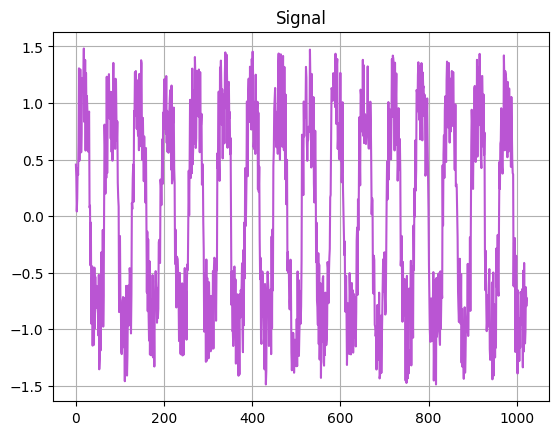

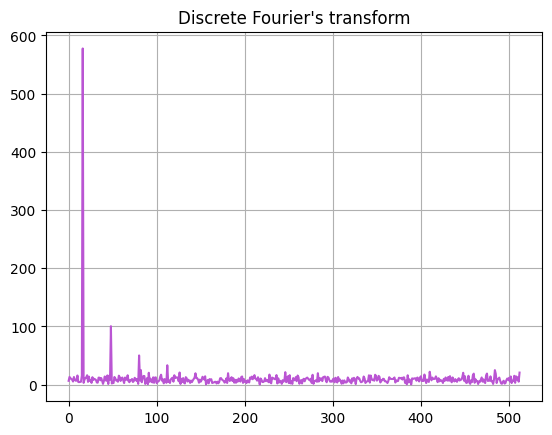

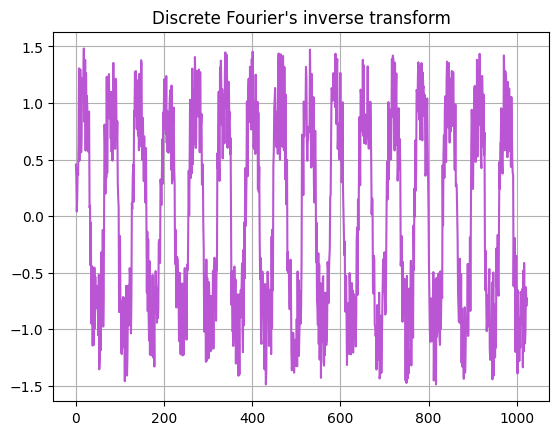

In [2]:
def DFT(y):
    N = len(y)
    c = np.zeros(N // 2 + 1, complex)
    for k in range(N // 2 + 1):
        for n in range(N):
            c[k] += y[n] * np.exp(-2j * math.pi * k * n / N)
    return c


y = np.loadtxt("pitch.txt", float)
plt.plot(y, color = mc, label = 'Signal')
plt.title('Signal')
plt.grid()
plt.show()
c = DFT(y)
plt.plot(abs(c), color = mc)
plt.title('Discrete Fourier\'s transform')
plt.grid()
plt.show()

def iDFT(c):
    N = 2 * len(c) - 2
    y = np.zeros(N, float)
    c2 = np.zeros(N, complex)
    c2[:len(c)] = c[:]
    for r in range(len(c), N):
        c2[r] = np.conj(c[N - r])
    for n in range(N):
        for k in range(N):
            y[n] += c2[k] * np.exp(2j * np.pi * k * n / N)
    return y / N

y2 = iDFT(c)


plt.plot(y2, color = mc)
plt.title('Discrete Fourier\'s inverse transform')
plt.grid()
plt.show()

### Transformada de Fourier en 2 dimensiones.

- La transformada de Fourier discreta se puede generalizar de forma trivial a funciones de más de una variable.


- En el caso particular de una función de dos dimensiones, dada una muestra  con $M\times N$ puntos, si fijamos la coordenada $x$ a la fila $m$:

    $$c_{ml}=\sum_{n=0}^{N-1}y_{mn}\exp\left(-i\frac{2\pi l n}{N}\right).$$


- Variando ahora cada una de la filas:

    $$c_{kl}=\sum_{m=0}^{M-1}\sum_{n=0}^{N-1}y_{mn}\exp\left[-2i\pi\left(\frac{ k m}{M}+\frac{ l n}{N}\right)\right],$$

    que proporciona el valor de los coeficientes de Fourier para una función en dos dimensiones. 

- La correspondiente transformada de Fourier inversa será:

    $$y_{mn}=\frac{1}{M N}\sum_{k=0}^{M-1}\sum_{l=0}^{N-1}c_{kl}\exp\left[2i\pi\left(\frac{ k m}{M}+\frac{ l n}{N}\right)\right].$$


- Si la función es real, es importante notar que mientras que al fijar una fila el valor la transformada de función discreta es la de una función real, al variar las filas, estamos haciendo la transformada de la función:

    $$\sum_{n=0}^{N-1}y_{mn}\exp\left(-i\frac{2\pi l n}{N}\right),$$

    que es compleja.

- Por tanto, en este caso tendremos que calcular $M\times \left(\frac{1}{2}N+1\right)$ si $N$ es par $M\times \frac{1}{2}\left(N+1\right)$ si $N$ es impar. 


- Las tranformadas de Fourier de dos dimensiones se utilizan de forma general en el tratamiento y procesamiento de imágenes, por ejemplo en:
<br/>

    - en astronomía para analizar señales de estrellas y galaxias.
    - en la microscopía electrónica.

---

## Transformada de Fourier de funciones simples.

---

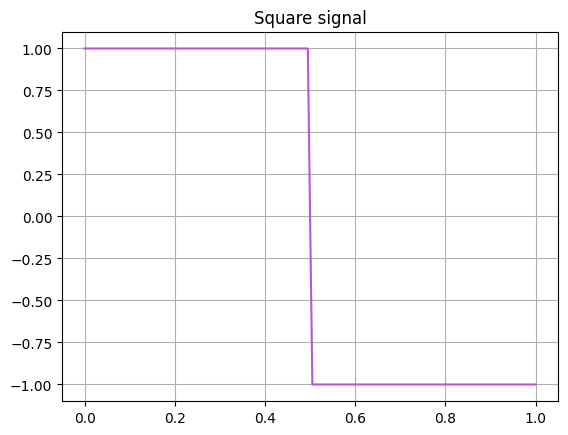

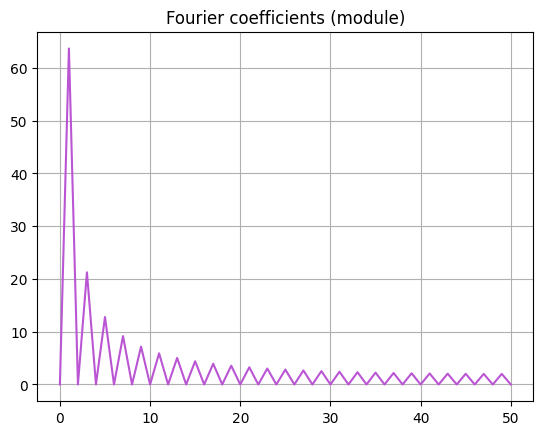

In [3]:
def square_signal(A, T):
    x = np.linspace(0, T, 100)
    y = np.zeros(np.shape(x))
    for i in range(len(x)):
        if x[i] < T / 2:
            y[i] = A
        else:
            y[i] = -A
    return x, y


x, y = square_signal(1, 1)
plt.plot(x, y, color = mc)
plt.title('Square signal')
plt.grid()
plt.show()
plt.plot(abs(DFT(y)), color = mc)
plt.title('Fourier coefficients (module)')
plt.grid()
plt.show()


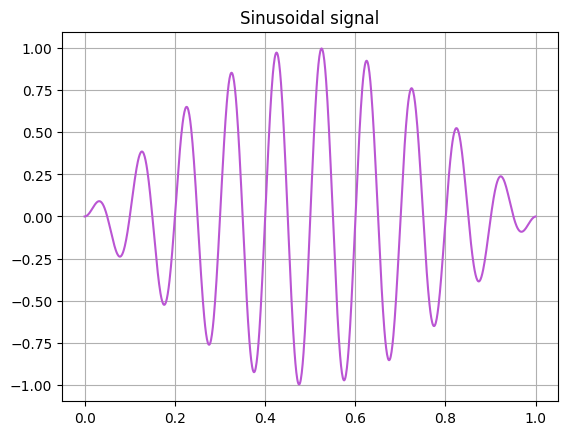

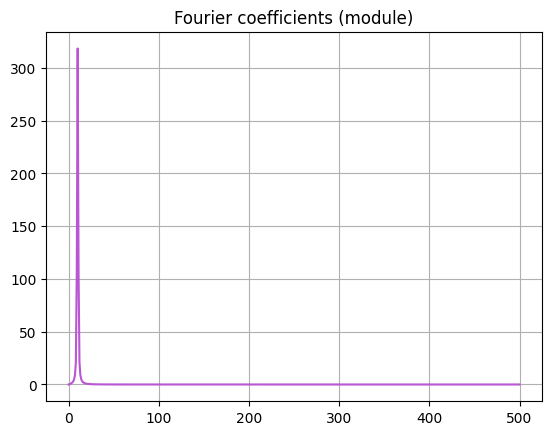

In [4]:
def sinusoidal(x):
    N = len(x)
    y = np.zeros(np.shape(x))
    for n in range(N):
        y[n] = np.sin(n * math.pi / N) * np.sin(20 * math.pi * n / N)

    return y

x = np.linspace(0, 1, 1000)
y = sinusoidal(x)
plt.plot(x, y, color = mc)
plt.title('Sinusoidal signal')
plt.grid()
plt.show()

plt.plot(abs(DFT(y)), color = mc)
plt.title('Fourier coefficients (module)')
plt.grid()
plt.show()

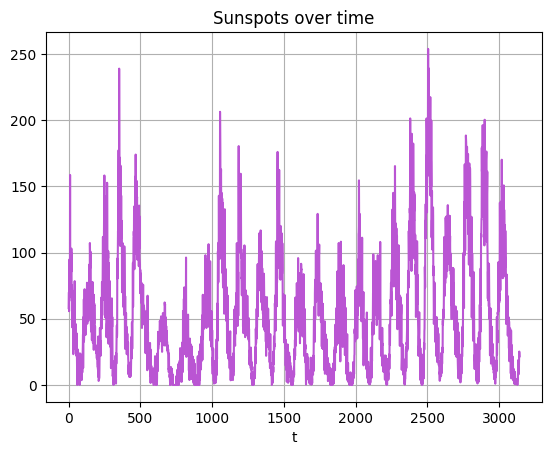

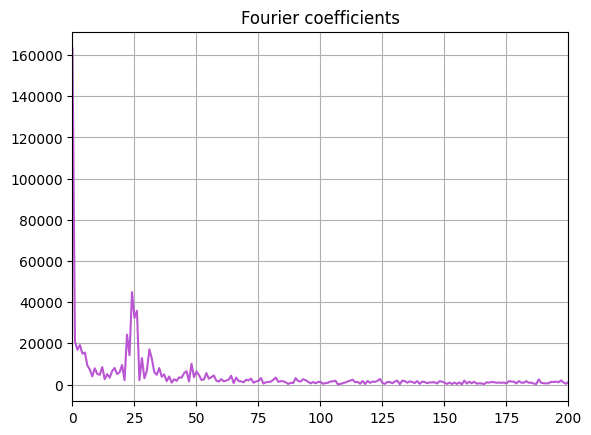

In [5]:
data = np.loadtxt('sunspots.txt')
x = data[:, 0]
y = data[:, 1]
plt.plot(x, y, color = mc)
plt.grid()
plt.title('Sunspots over time')
plt.xlabel('t')
plt.show()

c = DFT(y)
plt.plot(abs(c), color = mc)
plt.title('Fourier coefficients')
plt.grid()
plt.xlim(0, 200)
plt.show()

## Transformada de Fourier Rápida en numpy.

- Cómo no podía ser de otra forma ya hay un módulo en numpy en el que la transformada de Fourier rápida esta incorporada. Su implementación es además mucho más eficiente de la que hemos programado nosotros. 


- Es el módulo fft. 


- Este módulo incorpora las funciones rfft y irfft para la transformada de Fourier rápida de una muestra real y su inversa, respectivamente.


- También incorpora las funciones fft y ifft, en este caso para una muestra compleja. 


- Para muestras de dos dimensiones incorpora las funciones rfft2, irfft2 y fft2, ifft2. 


- Para funciones de más de dos dimensiones la función se llama rfftn, irfftn, y fftn, ifftn.

---

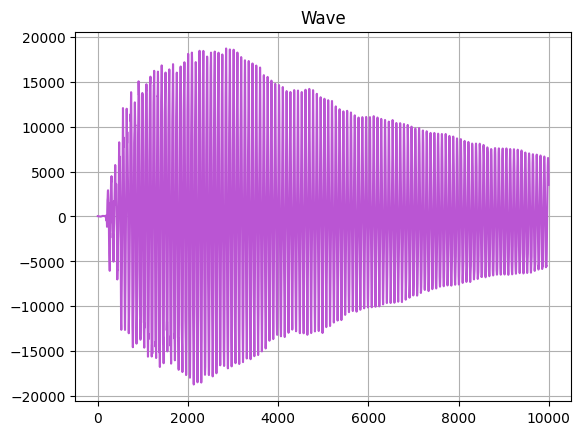

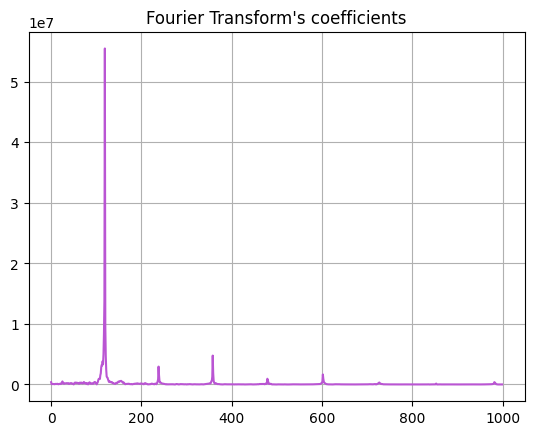

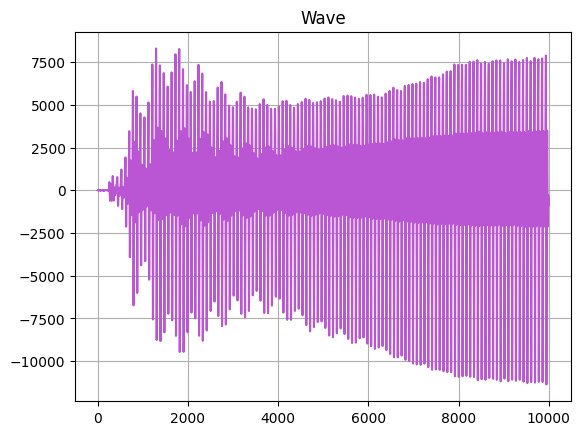

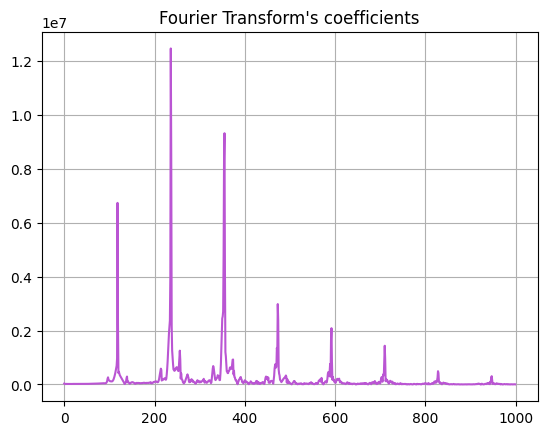

In [6]:
def señal(wave):
    c = fft.rfft(wave[:10000])
    plt.plot(wave[:10000], color = mc)
    plt.grid()
    plt.title('Wave')
    plt.show()
    
    plt.plot(abs(c[:1000]), color = mc)
    plt.grid()
    plt.title('Fourier Transform\'s coefficients')
    plt.show()

    

piano, trumpet=np.loadtxt("piano.txt"),np.loadtxt("trumpet.txt")
señal(piano)
señal(trumpet)

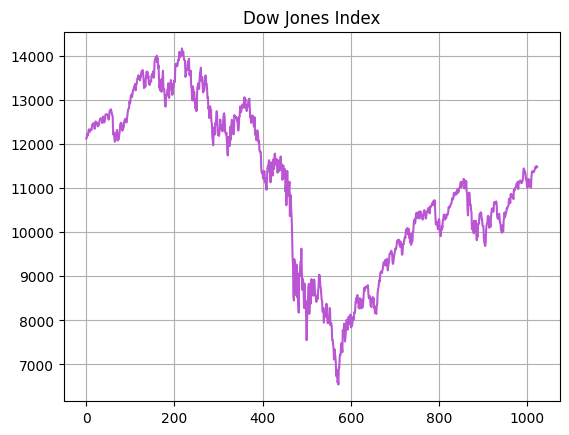

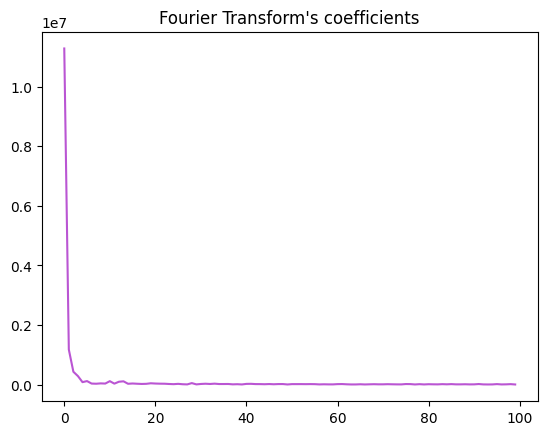

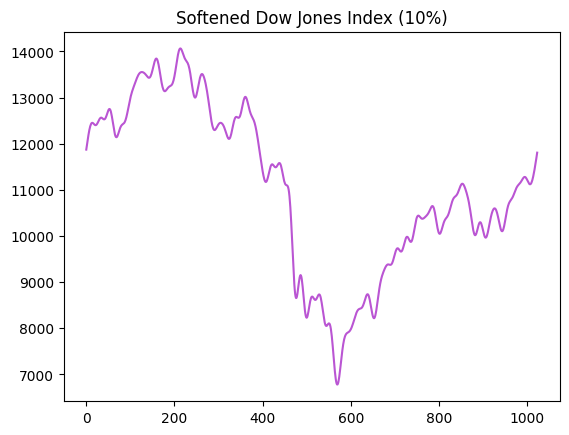

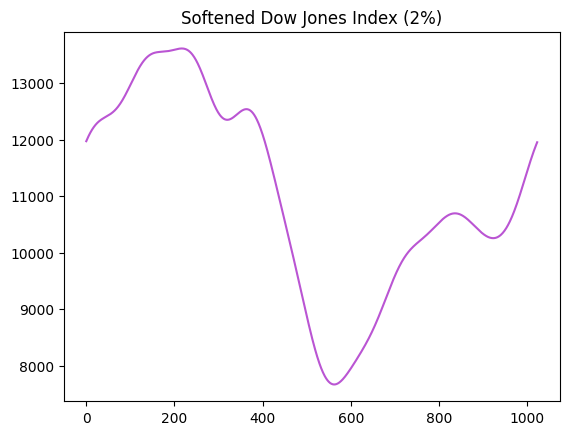

In [7]:
dow = np.loadtxt("dow.txt")
plt.plot(dow, color = mc)
plt.title('Dow Jones Index')
plt.grid()
plt.show()

c = fft.rfft(dow)
plt.plot(abs(c[:100]), color = mc)
plt.title('Fourier Transform\'s coefficients')
plt.show()

p = int(0.1 * len(c))
c[p:] = 0

r = fft.irfft(c)
plt.plot(abs(r), color = mc)
plt.title('Softened Dow Jones Index (10%)')
plt.show()

p2 = int(0.02 * len(c))
c[p2:] = 0
r2 = fft.irfft(c)
plt.plot(abs(r2), color = mc)
plt.title('Softened Dow Jones Index (2%)')
plt.show()

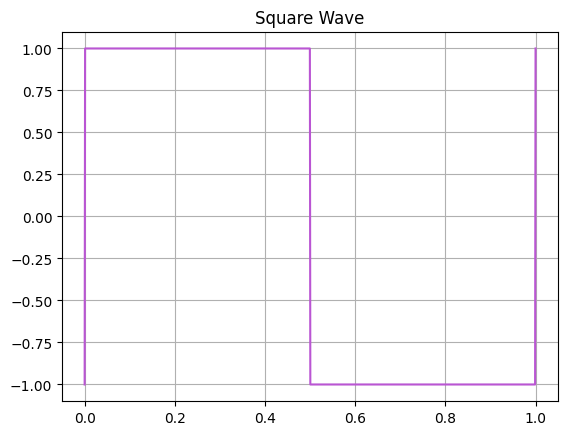

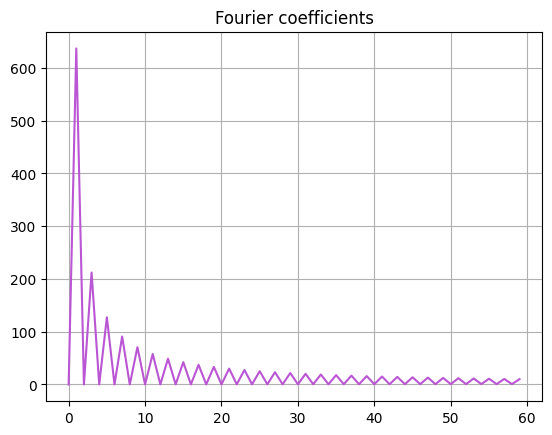

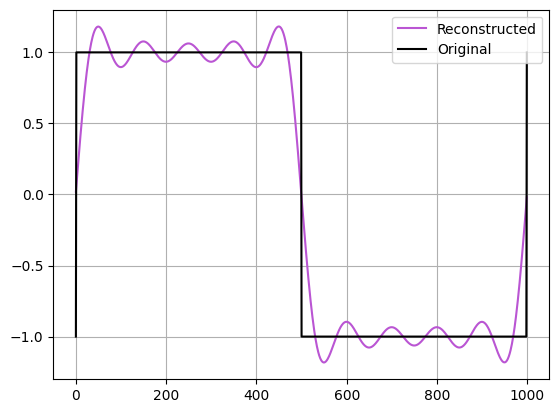

In [8]:
def f(t):
    y = np.zeros(np.shape(t))
    y[0] = -1
    for i in range(1, len(t)):
        if int(2 * t[i]) % 2 == 0:
            y[i] = 1
        else:
            y[i] = -1
    return y


t = np.linspace(0, 1, 1000)
y = f(t)
plt.plot(t, y, color = mc)
plt.title('Square Wave')
plt.grid()
plt.show()

c = fft.rfft(y)
plt.plot(abs(c[:60]), color = mc)
plt.title('Fourier coefficients')
plt.grid()
plt.show()

c[10:] = 0
r = fft.irfft(c)
plt.plot(r, color = mc, label="Reconstructed")
plt.plot(y, color = 'k', label="Original")
plt.grid()
plt.legend()
plt.show()


### Trasnformada de seno y coseno rápidas.

- La transformada del coseno y seno se puede obtener trivialmente usando la FFT pues no son  mas que una transformada de Fourier con una muestra simétrica o antisimétrica, respectivamente.


- Método para calcular una FCT y una FST:

   - Dada una muestra de N puntos, creamos una muestra con el doble de puntos por simetría especular par o impar dependiendo de si queremos una transformada seno o coseno.
   
   - Se realiza una FFT sobre la muestra obtenida.
   
   - Descartamos la parte imaginaria o real de los coeficientes para la transformada coseno y seno, respectivamente.

---

In [9]:
def fct(y):
    N = len(y)
    y2 = np.zeros(2 * N, float)

    for n in range(N):
        y2[n] = y[n] 
        y2[2 * N - 1 - n] = y[n]
    c = fft.rfft(y2)

    phi = np.exp(-1j * np.pi * np.arange(N) / (2 * N))
    return np.real(phi * c[:N])

def ifct(a):
    N = len(a)
    c = np.zeros(N, complex)
    phi = np.exp(1j * np.pi * np.arange(N) / (2 * N))
    c[:N] = phi * a

    return fft.irfft(c)[:N]


In [10]:
def fst(y):
    N = len(y)
    y2 = np.zeros(2 * N, float)
    y2[0] = y2[N-1] = 0

    for n in range(N):
        y2[n] = y[n]
        y2[2 * N - 1 - n] = -y[n]

    c = fft.rfft(y2)
    phi = np.exp(-1j * np.pi * np.arange(N) / (2 * N))
    a = -np.imag(phi * c[:N])
    a[0] = 0

    return a

def ifst(a):
    N = len(a)
    c = np.zeros(N + 1, complex)
    c[0] = c[N] = 0
    c[1:N] = -1j * a[:N]
    y = fft.irfft(c)[:N]
    y[0] = 0

    return y
